# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [18]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

# 1. Activos y rango del periodo
tickers = ["BA", "COP", "MRK"]
start_date = "2024-01-01"
end_date = "2026-01-01"

print("Información de las empresas seleccionadas:")
for t in tickers:
    info = yf.Ticker(t).info
    nombre = info.get('shortName', 'N/A')
    sector = info.get('sector', 'N/A')
    industria = info.get('industry', 'N/A')
    print(f"- {t}: {nombre} | Sector: {sector} | Industria: {industria}")
print("-" * 40)

# 2. Descarga de datos
df_raw = yf.download(tickers, start=start_date, end=end_date)

# 3. 5 primeras filas
display(df_raw.head())

Información de las empresas seleccionadas:
- BA: Boeing Company (The) | Sector: Industrials | Industria: Aerospace & Defense
- COP: ConocoPhillips | Sector: Energy | Industria: Oil & Gas E&P
- MRK: Merck & Company, Inc. | Sector: Healthcare | Industria: Drug Manufacturers - General
----------------------------------------


/tmp/ipykernel_1800/894790195.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_raw = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  3 of 3 completed


Price            Close                                High              \
Ticker              BA         COP         MRK          BA         COP   
Date                                                                     
2024-01-02  251.759995  108.177177  104.088921  258.589996  109.290326   
2024-01-03  243.910004  110.329880  105.495285  250.130005  110.559868   
2024-01-04  244.940002  107.156044  107.554276  248.279999  111.535012   
2024-01-05  249.000000  107.202034  107.747284  250.190002  108.342773   
2024-01-08  229.000000  105.334534  107.894356  233.850006  105.840510   

Price                          Low                                Open  \
Ticker             MRK          BA         COP         MRK          BA   
Date                                                                     
2024-01-02  104.162457  250.869995  107.496415  100.338636  257.279999   
2024-01-03  106.533973  243.000000  108.011603  104.934586  248.320007   
2024-01-04  108.142556  244.179993  106.962848  106.497207  244.580002   
2024-01-05  107.958693  245.039993  106.714460  107.214153  245.039993   
2024-01-08  108.363144  225.789993  103.476233  106.791332  228.000000   

Price                                 Volume                     
Ticker             COP         MRK        BA      COP       MRK  
Date                                                             
2024-01-02  107.790799  100.338636   5815200  4688400  11920100  
2024-01-03  108.508371  105.035691   7219900  4881900  10721900  
2024-01-04  110.955444  106.552356   5170700  5891500  11492200  
2024-01-05  108.094389  107.636979   3849700  3984600   6861500  
2024-01-08  105.757711  108.087385  40730400  6769600   8193100

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

### ℛ :
Es mucho mejor usar el grafico normalizado ya que los tres activos que estamos analizando cotizan en escalas de precios muy distintas, si solo miramos el grafico de precios originales la accion mas cara tendra un efecto visual mas dominante y parecerá que se mueve mas y esto va a distorcionar la percepcion del rendimiento real. Como despues lo normalizamos en base 100 esto nos permite dejar a los 3 activos en la misma linea de salida y nos permite tener una comparacion mas igualitaria.

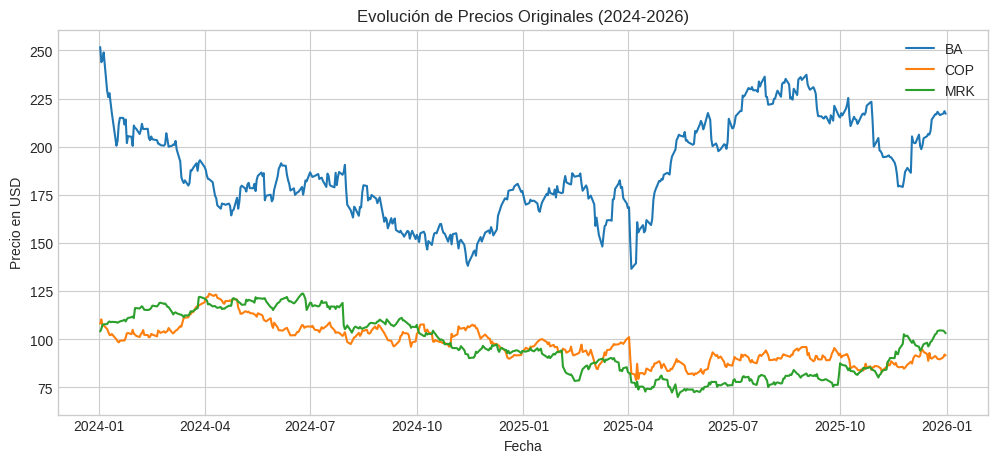

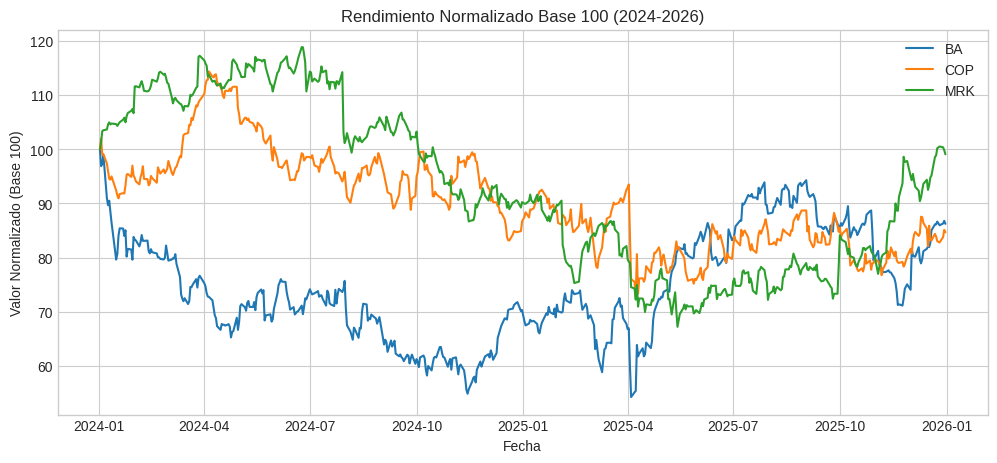

In [13]:
# 1. Extraer solo los precios de cierre(Close)
df_close = df_raw['Close'].copy()

# 2. Grafica de precios originales
plt.figure(figsize=(12, 5))
for ticker in tickers:
    plt.plot(df_close.index, df_close[ticker], label=ticker)

plt.title('Evolución de Precios Originales (2024-2026)')
plt.xlabel('Fecha')
plt.ylabel('Precio en USD')
plt.legend()
plt.show()

# 3. Normalizar en base 100 y graficar
df_norm = (df_close / df_close.iloc[0]) * 100

plt.figure(figsize=(12, 5))
for ticker in tickers:
    plt.plot(df_norm.index, df_norm[ticker], label=ticker)

plt.title('Rendimiento Normalizado Base 100 (2024-2026)')
plt.xlabel('Fecha')
plt.ylabel('Valor Normalizado (Base 100)')
plt.legend()
plt.show()

## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

### ℛ :
- Observando el Boxplot, (BA) es el activo con mayor dispersion. su caja es mucho mas ancha y sus muchas son mas largas que (COP) y (MRK). esto significa que (BA) es mas una "Montaña Rusa", sus rendimientos financiero fluctuan de forma mas violenta.
- Si, los tres activos cuentan con outliders. esto contextualmente significa que por ejemplo en Boeing hay reportes de incidentes en los aviones, sorporesas en reportes de ganancias o decisiones fuertes de la Reserva Federal.

El activo más volátil es: BA


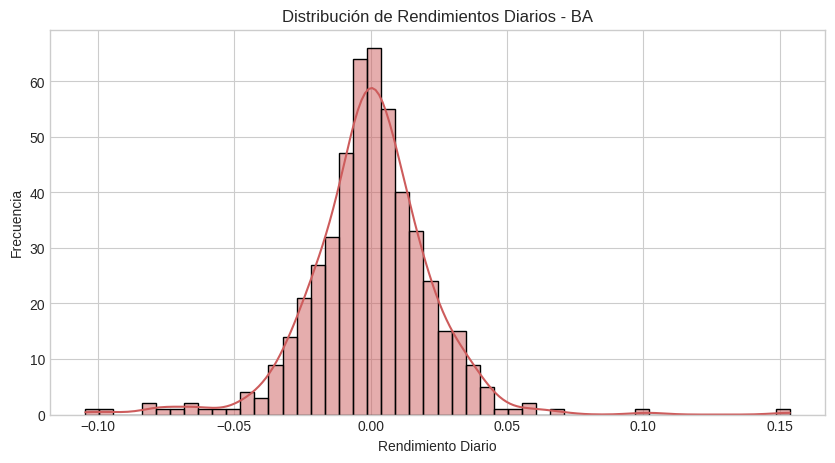

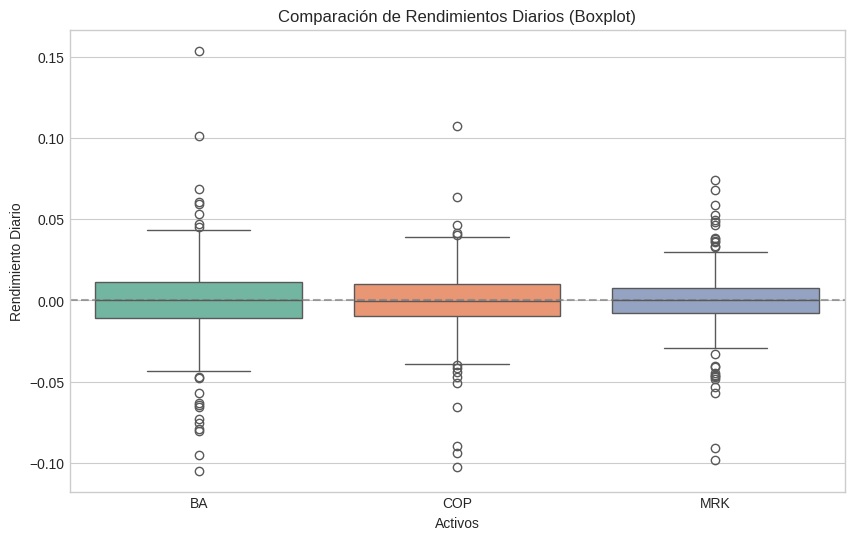

In [19]:
# 1. Calcular rendimientos y quitar nans
rendimientos = df_close.pct_change().dropna()

# 2. Histograma del activo más volátil
volatilidades = rendimientos.std()
activo_mas_volatil = volatilidades.idxmax()
print(f"El activo más volátil es: {activo_mas_volatil}")

plt.figure(figsize=(10, 5))
sns.histplot(rendimientos[activo_mas_volatil], bins=50, kde=True, color='indianred')
plt.title(f'Distribución de Rendimientos Diarios - {activo_mas_volatil}')
plt.xlabel('Rendimiento Diario')
plt.ylabel('Frecuencia')
plt.show()

# 3. Boxplot comparativo
plt.figure(figsize=(10, 6))
sns.boxplot(data=rendimientos, palette="Set2")
plt.title('Comparación de Rendimientos Diarios (Boxplot)')
plt.ylabel('Rendimiento Diario')
plt.xlabel('Activos')
plt.axhline(0, color='gray', linestyle='--', alpha=0.7)
plt.show()

## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

### ℛ :
- Pues todas las correlaciones son bastante bajas, por lo tanto no hay ninguna cercana a 1 o -1, y esto es bastante bueno para un portafolio. si quisiera armar un portafolio para diversificar y proteger mi capital. mezclaria (BA) y (MRK). Su correlacion es bajisima (0.079), esto significa que si los aviones de (BA) les va mal un dia pues a (MRK) les va y les viene ya que los movimientos de cada mercado respectivamente son independientes.

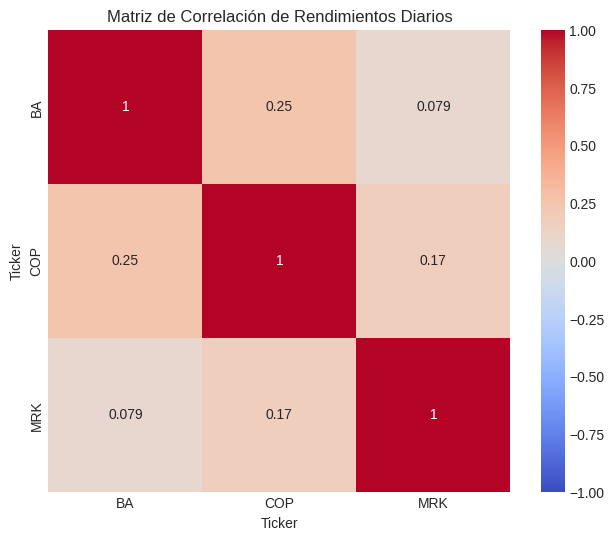

In [4]:
# 1. Calcular matriz de correlación de Pearson
matriz_corr = rendimientos.corr()

# 2. Dibujar el Heatmap utilizando Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True)
plt.title('Matriz de Correlación de Rendimientos Diarios')
plt.show()

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

### Conclusion:
Tras analizar este portafolio, vemos perfiles de riesgo muy marcados. Por un lado, tenemos a Merck (MRK) como nuestro pilar de estabilidad; es el activo menos riesgoso (desviación estándar de 0.0164) y el único con una media de retorno ligeramente positiva. Por otro lado, Boeing (BA) es nuestra apuesta de alto riesgo, con una volatilidad muy superior (0.0227) y retornos promedio casi nulos en este periodo. ConocoPhillips (COP) se mantiene en un punto intermedio. La buena noticia es que los tres activos casi no están correlacionados entre sí. Al combinarlos, podemos construir un portafolio resistente que no se hunda por el fracaso de un solo sector económico.

In [5]:
# Generar resumen estadístico
# Calculamos las métricas solicitadas
resumen_stats = pd.DataFrame({
    'Media': rendimientos.mean(),
    'Mediana': rendimientos.median(),
    'Desviación Est.': rendimientos.std(),
    'Mínimo': rendimientos.min(),
    'Máximo': rendimientos.max()
})

print("Resumen Estadístico de Rendimientos Diarios:")
display(resumen_stats.round(4))

Resumen Estadístico de Rendimientos Diarios:


,Media,Mediana,Desviación Est.,Mínimo,Máximo
Ticker,,,,,
BA,-0.0000,-0.0000,0.0227,-0.1047,0.1537
COP,-0.0002,-0.0003,0.0181,-0.1023,0.1071
MRK,0.0001,0.0001,0.0164,-0.0981,0.0739
